# **Problem Statement**

**Principle Component Analysis**

Write codes in Python to perform PCA and understand why we need such unsupervised learning method. Please implement PCA as it has been done in the Nature Primer. See here. You will ALMOST (the data point values may differ a bit, but the patterns will be similar) be reproducing Figure 1 of the paper. The data for all 105 patient samples are organized in three files.

    data/class.tsv: has the labels. 1 (ER+ breast cancer), 0 (ER- breast cancer).

    data/filtered.tsv.gz: complete dataset. Header is the ID for genes.

    data/columns.tsv.gz: ID to gene name mapping.

For example, 4404 is the ID for gene XBP1 (Figure 1a - Y-axis).

Your goal is to:

Extract XBP1 and GATA3 expression levels in all 105 patients, and generate the scatter plot as seen in 1a (coloring should be done by the class). Remember that pattern in your plot should be similar to the paper.

Run PCA on the matrix and project these 2-D points on PC1. Generate Fgure 1c.

See the plot below.

# **Approach**

To recreate the analysis shown in **Figure 1** of the paper using gene expression data, we focus on two specific genes: **GATA3** and **XBP1**, both of which are known to be relevant in breast cancer biology. The goal is to understand how the expression of these two genes can be used to distinguish between **estrogen receptor-positive (ER+)** and **estrogen receptor-negative (ER−)** breast cancer samples, and to explore how Principal Component Analysis (PCA) helps with this.

\

### Step 1: Understanding the Data

We start with two datasets:
1. **Gene expression data**: Each sample (representing a patient) has expression levels for many genes. We specifically extract the expression values for the genes GATA3 and XBP1.
2. **Class labels**: This dataset tells us whether each sample is ER+ (coded as 1) or ER− (coded as 0).

These class labels are essential because they help us later color-code the samples in plots and assess how well the genes or PCA separates the two groups.

\


### Step 2: Visualizing Raw Gene Expression (Figure 1a)

Using the expression values of GATA3 and XBP1, we make a scatter plot where each point represents a sample. The x-axis is GATA3 expression, and the y-axis is XBP1 expression.

To distinguish between ER+ and ER− samples, we use color: ER+ samples are plotted in red, and ER− samples in black. This allows us to visually assess whether these two genes already show any natural separation between the groups.

In this plot, we can see some tendency of ER+ samples clustering toward higher GATA3 expression, but it’s not entirely clear-cut.

\


### Step 3: Applying Principal Component Analysis (PCA)

PCA is a mathematical method used to identify the main directions (or "axes") in which the data varies the most. In this context, it finds the best new coordinate system to explain the variation in the two-gene expression data.

We apply PCA to the GATA3-XBP1 expression matrix. PCA gives us two new axes:
- **PC1 (Principal Component 1)**: the direction in which the data varies the most.
- **PC2**: the second-most variable direction, which is perpendicular to PC1.

PC1 is particularly interesting because it can often capture the primary biological difference between sample groups.

\

### Step 4: Visualizing PCA Direction (Figure 1b)

Once we obtain PC1 and PC2, we visualize them as arrows on the original GATA3-XBP1 scatter plot. These arrows show how PCA has rotated the original axes to find the directions of greatest variation.

Importantly, we check the orientation of PC1. If ER+ samples tend to project to the right on PC1 (i.e., have higher PC1 scores), we keep the direction as is. Otherwise, we flip it. This makes interpretation more intuitive and consistent with the paper.

\

### Step 5: Projecting Samples onto PC1 (Figure 1c)

To better visualize how well PC1 separates the ER+ and ER− groups, we take all samples and compute their projection (or “shadow”) onto the PC1 axis. We then make three separate scatter plots:
1. One for **all samples**.
2. One for **only ER− samples**.
3. One for **only ER+ samples**.

This projection shows that ER+ samples tend to cluster on one side of PC1, and ER− samples on the other. This confirms that PCA, even with just two genes, captures meaningful biological separation.

\

### Step 6: Assessing PCA Effectiveness

Finally, we calculate how much of the total variability in the original data is explained by PC1 and PC2. In this case, PC1 explains a significant portion of the variance, which tells us that it effectively captures the key differences among samples.

\


By using PCA on just two genes—GATA3 and XBP1—we are able to:
- Visualize how these genes are expressed across different breast cancer samples.
- See some natural separation between ER+ and ER− groups.
- Use PCA to reduce the data to a single informative direction (PC1) that more clearly separates the groups.

This exercise demonstrates the power of PCA in uncovering patterns in biological data, even with a minimal number of features.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load class labels: 1 for ER+, 0 for ER-
labels = pd.read_csv('class.tsv', sep='\t', header=None)[0].values

# Extract gene symbol to ID mapping
def load_gene_id(gene_name):
    # Directly read the extracted columns.tsv file
    mapping_df = pd.read_csv('columns.tsv', sep='\t', comment='#')
    return mapping_df[mapping_df['GeneSymbol'] == gene_name]['ID'].values[0]

gata3_id = load_gene_id('GATA3')
xbp1_id = '4404'

# Load expression data directly (filtered.tsv is no longer compressed)
expr_data = pd.read_csv('filtered.tsv', sep='\t', index_col=0)

# Clean column names (sometimes whitespaces present)
expr_data.columns = expr_data.columns.astype(str).str.strip()

# Extract expression levels
gata3_vals = expr_data[str(gata3_id)].values
xbp1_vals = expr_data[str(xbp1_id)].values

# Assign colors by class
color_map = ['red' if label == 1 else 'black' for label in labels]

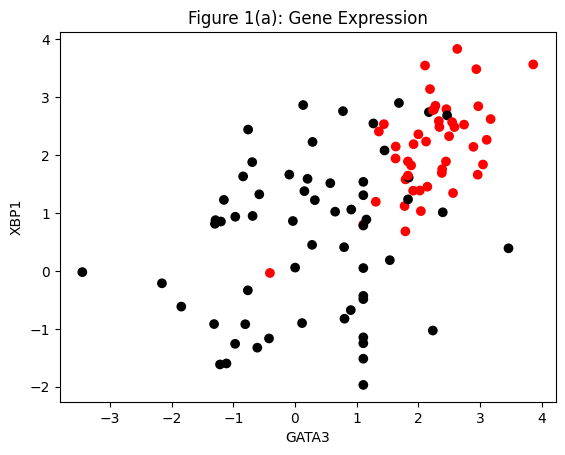

In [2]:
def plot_scatter(x, y, labels, title, xlab, ylab, filename):
    plt.figure()
    plt.scatter(x, y, c=labels)
    plt.xlabel(xlab)
    plt.ylabel(ylab)
    plt.title(title)
    plt.savefig(filename)
    plt.show()

plot_scatter(gata3_vals, xbp1_vals, color_map,
             'Figure 1(a): Gene Expression', 'GATA3', 'XBP1', 'fig1a.png')

In [3]:
def manual_pca(X):
    X_centered = X - np.mean(X, axis=0)
    cov = np.cov(X_centered, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(cov)
    idx = np.argsort(eigvals)[::-1]
    return eigvecs[:, idx], eigvals[idx], X_centered

# Stack GATA3 and XBP1 into matrix
X = np.column_stack((gata3_vals, xbp1_vals))
eigvecs, eigvals, X_centered = manual_pca(X)

pc1, pc2 = eigvecs[:, 0], eigvecs[:, 1]
proj_pc1 = X_centered @ pc1
proj_pc2 = X_centered @ pc2

# Ensure PC1 separates ER+ and ER- consistently
if np.mean(proj_pc1[labels == 1]) < np.mean(proj_pc1[labels == 0]):
    pc1 *= -1
    proj_pc1 *= -1

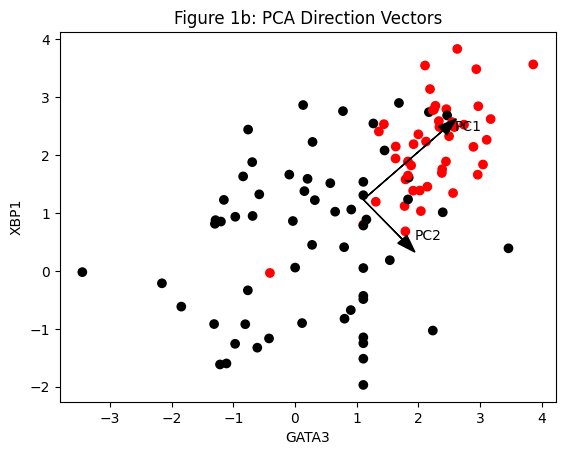

In [4]:
# Figure 1b: Visualize PC directions

plt.figure()
plt.scatter(gata3_vals, xbp1_vals, c=color_map)

mean_gata3, mean_xbp1 = np.mean(gata3_vals), np.mean(xbp1_vals)
scale1, scale2 = np.sqrt(eigvals[0]), np.sqrt(eigvals[1])

# Draw PC arrows
plt.arrow(mean_gata3, mean_xbp1, pc1[0]*scale1, pc1[1]*scale1,
          head_width=0.2, head_length=0.3, fc='black')
plt.arrow(mean_gata3, mean_xbp1, pc2[0]*scale2, pc2[1]*scale2,
          head_width=0.2, head_length=0.3, fc='black')

plt.text(mean_gata3 + pc1[0]*scale1 + 0.2, mean_xbp1 + pc1[1]*scale1, 'PC1')
plt.text(mean_gata3 + pc2[0]*scale2 + 0.2, mean_xbp1 + pc2[1]*scale2, 'PC2')
plt.xlabel('GATA3')
plt.ylabel('XBP1')
plt.title('Figure 1b: PCA Direction Vectors')
plt.savefig('fig1b.png')
plt.show()

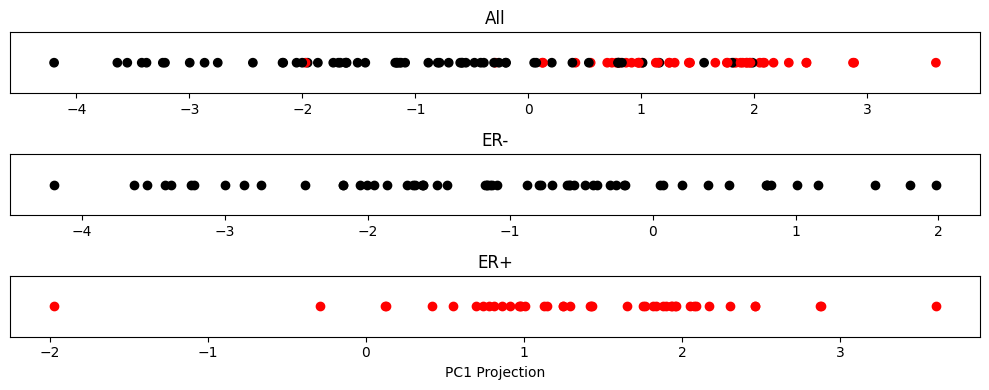

PC1 explains 0.7792 of variance
PC2 explains 0.2208 of variance


In [5]:
# Figure 1c: Projected samples on PC1

plt.figure(figsize=(10, 4))

# Subplot: All samples
plt.subplot(3, 1, 1)
plt.scatter(proj_pc1, np.zeros_like(proj_pc1), c=color_map)
plt.yticks([]); plt.title('All')

# Subplot: ER- samples
plt.subplot(3, 1, 2)
plt.scatter(proj_pc1[labels == 0], np.zeros_like(proj_pc1[labels == 0]), c='black')
plt.yticks([]); plt.title('ER-')

# Subplot: ER+ samples
plt.subplot(3, 1, 3)
plt.scatter(proj_pc1[labels == 1], np.zeros_like(proj_pc1[labels == 1]), c='red')
plt.yticks([]); plt.title('ER+')
plt.xlabel('PC1 Projection')

plt.tight_layout()
plt.savefig('fig1c.png')
plt.show()


var_explained_pc1 = eigvals[0] / np.sum(eigvals)
var_explained_pc2 = eigvals[1] / np.sum(eigvals)
print(f"PC1 explains {var_explained_pc1:.4f} of variance")
print(f"PC2 explains {var_explained_pc2:.4f} of variance")